# Olympics 2028 Medal Predictor

**Goal**: Predict number of medals per country for the 2028 Los Angeles Olympics, with specific attention to home field advantage and economic factors.

**Structure of this notebook**:
1. Data loading & exploration
2. Feature engineering
3. Model training & comparison
4. Validation & evaluation
5. 2028 predictions

---
## 1. Data Loading & Exploration

### What I'm doing
Loading the two main datasets: historical Olympic medal data from Kaggle, and GDP/economic data from the World Bank. Before any modelling, I want to understand the shape and quality of the data — missing values, distributions, and obvious patterns.

### Data sources
- `athlete_events.csv` — 120 years of Olympic athlete results from Kaggle
- `world_bank_gdp.csv` — GDP per capita by country and year from World Bank

### Notes

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
athletes = pd.read_csv('../data/raw/athlete_events.csv')
gdp = pd.read_csv('../data/raw/world_bank_gdp.csv', skiprows=4)

print('Athletes dataset:', athletes.shape)
print('GDP dataset:', gdp.shape)
gdp.head()

Athletes dataset: (271116, 15)
GDP dataset: (266, 71)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN,NaN


In [20]:
# Keep only Summer Olympics — 2028 LA is a Summer Games
athletes = athletes[athletes['Season'] == 'Summer']

print('Years after filtering:', sorted(athletes['Year'].unique()))
print('Total rows:', athletes.shape[0])

Years after filtering: [np.int64(1896), np.int64(1900), np.int64(1904), np.int64(1906), np.int64(1908), np.int64(1912), np.int64(1920), np.int64(1924), np.int64(1928), np.int64(1932), np.int64(1936), np.int64(1948), np.int64(1952), np.int64(1956), np.int64(1960), np.int64(1964), np.int64(1968), np.int64(1972), np.int64(1976), np.int64(1980), np.int64(1984), np.int64(1988), np.int64(1992), np.int64(1996), np.int64(2000), np.int64(2004), np.int64(2008), np.int64(2012), np.int64(2016)]
Total rows: 222552


In [21]:
# Aggregate medals per country per year
# Explanation: each row is an athlete-event, so we need to count medals at country level
medals = (
    athletes[athletes['Medal'].notna()]
    .groupby(['Year', 'NOC', 'Medal'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
medals.columns.name = None
medals = medals.rename(columns={'Gold': 'gold', 'Silver': 'silver', 'Bronze': 'bronze'})
medals['total'] = medals['gold'] + medals['silver'] + medals['bronze']

print(medals.shape)
medals.head(10)

(1275, 6)


,Year,NOC,bronze,gold,silver,total
0,1896,AUS,1,2,0,3
1,1896,AUT,2,2,1,5
2,1896,DEN,3,1,2,6
3,1896,FRA,2,5,4,11
4,1896,GBR,3,3,3,9
5,1896,GER,2,25,5,32
6,1896,GRE,20,10,18,48
7,1896,HUN,3,2,1,6
8,1896,SUI,0,1,2,3
9,1896,USA,2,11,7,20


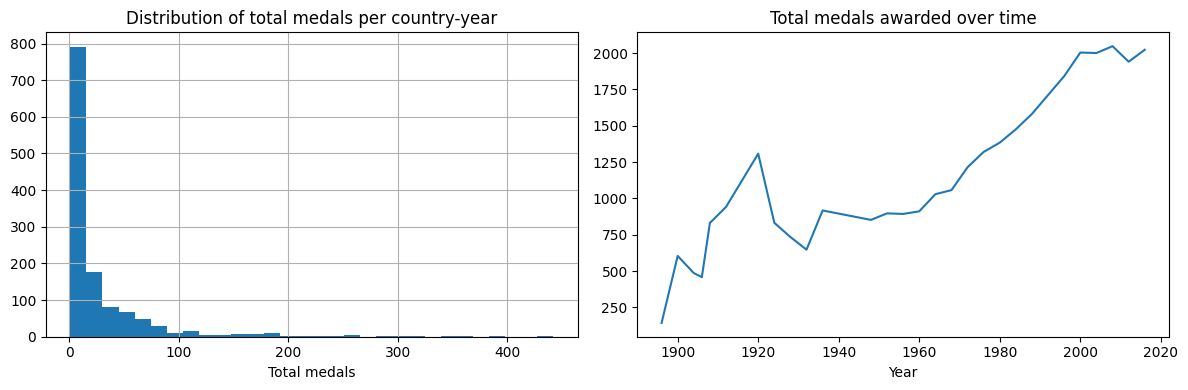

In [ ]:
# Quick EDA: distribution of total medals per country
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

medals['total'].hist(bins=30, ax=axes[0])
axes[0].set_title('Distribution of total medals per country-year')
axes[0].set_xlabel('Total medals')

medals.groupby('Year')['total'].sum().plot(ax=axes[1])
axes[1].set_title('Total medals awarded over time')

plt.tight_layout()
plt.savefig('../data/processed/eda_medals_distribution.png', dpi=150)
plt.show()

#### EDA observations
- uneven distribution
- historical events have big effects

### Observations
- Distribution is heavily skewed — most countries win very few medals per Olympics
- Each bar represents a country-year combination, not a unique country
- Large countries (USA, Russia, GBR) appear ~30 times and dominate the right tail
- Spikes and drops in total medals over time reflect historical events:
  boycotts (1980, 1984), addition of new sports, and the collapse of the USSR in 1991
- Predictions for smaller countries will be less reliable due to limited historical data

---
## 2. Feature Engineering

### What I'm doing
Building the features that the model will use to make predictions. This is the most important step — a model is only as good as the signals you feed it.

### Key features and the reasoning behind each

| Feature | Rationale |
|---|---|
| `is_host` | Host nations historically win more medals — the home crowd effect |
| `home_boost_multiplier` | Not all nations benefit equally from hosting — this captures how much *this* country has historically benefited |
| `rolling_3game_avg` | Recent form matters more than distant history |
| `gdp_per_capita` | Wealthier countries invest more in sport infrastructure |
| `trend_slope` | Is this country improving or declining over recent games? |

In [23]:
# Host nations — manually defined from historical records
HOST_NATIONS = {
    1896: 'GRE', 1900: 'FRA', 1904: 'USA', 1908: 'GBR', 1912: 'SWE',
    1920: 'BEL', 1924: 'FRA', 1928: 'NED', 1932: 'USA', 1936: 'GER',
    1948: 'GBR', 1952: 'FIN', 1956: 'AUS', 1960: 'ITA', 1964: 'JPN',
    1968: 'MEX', 1972: 'GER', 1976: 'CAN', 1980: 'URS', 1984: 'USA',
    1988: 'KOR', 1992: 'ESP', 1996: 'USA', 2000: 'AUS', 2004: 'GRE',
    2008: 'CHN', 2012: 'GBR', 2016: 'BRA', 2020: 'JPN', 2024: 'FRA',
    2028: 'USA'  # LA 2028
}

medals['is_host'] = medals.apply(
    lambda row: 1 if HOST_NATIONS.get(row['Year']) == row['NOC'] else 0, axis=1
)

print('Host nation rows:', medals['is_host'].sum())
medals[medals['is_host'] == 1][['Year', 'NOC', 'gold', 'total']].head(10)

Host nation rows: 27


,Year,NOC,gold,total
6,1896,GRE,10,48
19,1900,FRA,52,235
45,1904,USA,128,394
72,1908,GBR,147,368
100,1912,SWE,103,190
103,1920,BEL,57,188
132,1924,FRA,37,110
176,1928,NED,20,57
216,1932,USA,81,189
228,1936,GER,93,224


In [24]:
# Rolling 3-game medal average per country
# Sort first — rolling requires chronological order
medals = medals.sort_values(['NOC', 'Year'])

medals['rolling_3game_avg'] = (
    medals.groupby('NOC')['total']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# Why shift(1)? We use past performance only — never the current game's result.
# This prevents data leakage.
medals[['Year', 'NOC', 'total', 'rolling_3game_avg']].head(15)

,Year,NOC,total,rolling_3game_avg
1018,2008,AFG,1,NaN
1104,2012,AFG,1,1.000000
669,1988,AHO,1,NaN
622,1984,ALG,2,NaN
721,1992,ALG,2,2.000000
785,1996,ALG,3,2.000000
864,2000,ALG,5,2.333333
1019,2008,ALG,2,3.333333
1105,2012,ALG,1,3.333333
1189,2016,ALG,2,2.666667


In [25]:
# Reshape GDP from wide to long format
gdp_long = gdp.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[str(y) for y in range(1960, 2024)],
    var_name='Year',
    value_name='gdp_per_capita'
)

# Clean up
gdp_long['Year'] = gdp_long['Year'].astype(int)
gdp_long = gdp_long.dropna(subset=['gdp_per_capita'])

print(gdp_long.shape)
gdp_long.head(10)

(14321, 4)


,Country Name,Country Code,Year,gdp_per_capita
1,Africa Eastern and Southern,AFE,1960,186.089204
3,Africa Western and Central,AFW,1960,121.936832
9,Argentina,ARG,1960,778.251707
13,Australia,AUS,1960,1813.431099
14,Austria,AUT,1960,939.914815
16,Burundi,BDI,1960,70.905100
17,Belgium,BEL,1960,1290.286072
18,Benin,BEN,1960,89.856925
19,Burkina Faso,BFA,1960,69.150246
20,Bangladesh,BGD,1960,82.481277


In [37]:
# Map NOC codes to World Bank country codes
# World Bank uses ISO-3, Kaggle uses NOC — some are different
noc_to_iso = {
    # Original mappings
    'USA': 'USA', 'GBR': 'GBR', 'GER': 'DEU', 'FRA': 'FRA',
    'AUS': 'AUS', 'CHN': 'CHN', 'RUS': 'RUS', 'ITA': 'ITA',
    'CAN': 'CAN', 'JPN': 'JPN', 'KOR': 'KOR', 'NED': 'NLD',
    'SWE': 'SWE', 'NOR': 'NOR', 'FIN': 'FIN', 'ESP': 'ESP',
    'POL': 'POL', 'HUN': 'HUN', 'CUB': 'CUB', 'ROU': 'ROU',
    'BUL': 'BGR', 'DEN': 'DNK', 'SUI': 'CHE', 'AUT': 'AUT',
    'BRA': 'BRA', 'GRE': 'GRC', 'CZE': 'CZE', 'UKR': 'UKR',
    'BEL': 'BEL', 'MEX': 'MEX', 'ARG': 'ARG', 'NZL': 'NZL',
    'RSA': 'ZAF', 'JAM': 'JAM', 'KEN': 'KEN', 'ETH': 'ETH',
    'TUR': 'TUR', 'IRI': 'IRN', 'POR': 'PRT', 'GRN': 'GRD',
    'KOS': 'XKX', 'MON': 'MCO', 'MRI': 'MUS', 'TGA': 'TON', 
    'TPE': 'TWN',
    # Extended mappings
    'AFG': 'AFG', 'ALG': 'DZA', 'ARM': 'ARM', 'AZE': 'AZE',
    'BAH': 'BHS', 'BAR': 'BRB', 'BDI': 'BDI', 'BLR': 'BLR',
    'BOT': 'BWA', 'BRN': 'BHR', 'CHI': 'CHL', 'CIV': 'CIV',
    'CMR': 'CMR', 'COL': 'COL', 'CRC': 'CRI', 'CRO': 'HRV',
    'CYP': 'CYP', 'DJI': 'DJI', 'DOM': 'DOM', 'ECU': 'ECU',
    'EGY': 'EGY', 'ERI': 'ERI', 'EST': 'EST', 'FIJ': 'FJI',
    'GAB': 'GAB', 'GEO': 'GEO', 'GHA': 'GHA', 'GUA': 'GTM',
    'GUY': 'GUY', 'HAI': 'HTI', 'HKG': 'HKG', 'INA': 'IDN',
    'IND': 'IND', 'IRL': 'IRL', 'IRQ': 'IRQ', 'ISL': 'ISL',
    'ISR': 'ISR', 'JOR': 'JOR', 'KAZ': 'KAZ', 'KGZ': 'KGZ',
    'KSA': 'SAU', 'KUW': 'KWT', 'LAT': 'LVA', 'LIB': 'LBN',
    'LTU': 'LTU', 'LUX': 'LUX', 'MAR': 'MAR', 'MAS': 'MYS',
    'MDA': 'MDA', 'MGL': 'MNG', 'MKD': 'MKD', 'MNE': 'MNE',
    'MOZ': 'MOZ', 'NAM': 'NAM', 'NGR': 'NGA', 'NIG': 'NER',
    'PAK': 'PAK', 'PAN': 'PAN', 'PAR': 'PRY', 'PER': 'PER',
    'PHI': 'PHL', 'QAT': 'QAT', 'SEN': 'SEN', 'SGP': 'SGP',
    'SLO': 'SVN', 'SRB': 'SRB', 'SRI': 'LKA', 'SUD': 'SDN',
    'SUR': 'SUR', 'SVK': 'SVK', 'SYR': 'SYR', 'TAN': 'TZA',
    'THA': 'THA', 'TJK': 'TJK', 'TOG': 'TGO', 'TTO': 'TTO',
    'TUN': 'TUN', 'UAE': 'ARE', 'UGA': 'UGA', 'URU': 'URY',
    'UZB': 'UZB', 'VEN': 'VEN', 'VIE': 'VNM', 'ZAM': 'ZMB',
    'ZIM': 'ZWE',
    # Historical nations — map to successor state
    'URS': 'RUS', 'GDR': 'DEU', 'FRG': 'DEU', 'TCH': 'CZE',
    'YUG': 'SRB', 'SCG': 'SRB', 'EUN': 'RUS',
}

medals['iso_code'] = medals['NOC'].map(noc_to_iso)

# Merge medals with GDP
df = medals.merge(
    gdp_long,
    left_on=['Year', 'iso_code'],
    right_on=['Year', 'Country Code'],
    how='left'
)

print(df.shape)
print('Missing GDP values:', df['gdp_per_capita'].isna().sum())
print('Total rows:', df.shape[0])
print(f'Coverage: {(df["gdp_per_capita"].notna().sum() / len(df) * 100):.1f}%')
missing_mapping = medals[medals['iso_code'].isna()]['NOC'].unique()
print(f'Države bez mappinga: {len(missing_mapping)}')
print(sorted(missing_mapping))
print(medals['Year'].unique())
print(athletes['Season'].unique())
df.head()

(1275, 12)
Missing GDP values: 453
Total rows: 1275
Coverage: 64.5%
Države bez mappinga: 10
['AHO', 'ANZ', 'BER', 'BOH', 'IOA', 'ISV', 'PRK', 'PUR', 'UAR', 'WIF']
[2008 2012 1988 1984 1992 1996 2000 2016 1908 1912 1924 1928 1932 1936
 1948 1952 1956 1960 1964 1968 1972 2004 1896 1900 1904 1906 1920 1976
 1980]
['Summer']


,Year,NOC,bronze,gold,silver,total,is_host,rolling_3game_avg,iso_code,Country Name,Country Code,gdp_per_capita
0,2008,AFG,1,0,0,1,0,NaN,AFG,Afghanistan,AFG,381.733238
1,2012,AFG,1,0,0,1,0,1.0,AFG,Afghanistan,AFG,651.417134
2,1988,AHO,0,0,1,1,0,NaN,NaN,NaN,NaN,NaN
3,1984,ALG,2,0,0,2,0,NaN,DZA,Algeria,DZA,2524.380714
4,1992,ALG,1,1,0,2,0,2.0,DZA,Algeria,DZA,1802.693008


In [40]:
# Trend slope — is this country improving or declining?
def add_trend_slope(df, country_col, year_col, medal_col, window=4):
    """
    Calculate the trend (slope) of medal counts over last N games.
    Positive = improving, negative = declining, 0 = stable.
    """
    df = df.copy().sort_values([country_col, year_col])
    
    def slope(x):
        if len(x) < 2:
            return 0
        years = range(len(x))
        return np.polyfit(years, x, 1)[0]
    
    df['trend_slope'] = (
        df.groupby(country_col)[medal_col]
        .transform(lambda x: x.shift(1).rolling(window, min_periods=2).apply(slope))
    )
    df['trend_slope'] = df['trend_slope'].fillna(0)
    return df

df = add_trend_slope(df, 'NOC', 'Year', 'total')

print(df[['NOC', 'Year', 'total', 'rolling_3game_avg', 'trend_slope']].head(20))

    NOC  Year  total  rolling_3game_avg  trend_slope
0   AFG  2008      1                NaN          0.0
1   AFG  2012      1           1.000000          0.0
2   AHO  1988      1                NaN          0.0
3   ALG  1984      2                NaN          0.0
4   ALG  1992      2           2.000000          0.0
5   ALG  1996      3           2.000000          0.0
6   ALG  2000      5           2.333333          0.0
7   ALG  2008      2           3.333333          1.0
8   ALG  2012      1           3.333333          0.2
9   ALG  2016      2           2.666667         -0.9
10  ANZ  1908     19                NaN          0.0
11  ANZ  1912     10          19.000000          0.0
12  ARG  1924     10                NaN          0.0
13  ARG  1928     26          10.000000          0.0
14  ARG  1932      4          18.000000          0.0
15  ARG  1936     11          13.333333          0.0
16  ARG  1948     11          13.666667         -1.9
17  ARG  1952      6           8.666667       

In [41]:
df.to_csv('../data/processed/medals_features.csv', index=False)

## Phase 2 summary

Built 4 key features:
- is_host: binary flag for host nation
- rolling_3game_avg: average medals over last 3 Olympics (no data leakage)
- gdp_per_capita: World Bank economic indicator, 64% coverage
- trend_slope: whether a country is improving or declining

GDP coverage is 64% — missing values are mostly small nations with few medals.
Large medallist countries (USA, CHN, RUS, GBR) are fully covered.

---
## 3. Model Training

### What I'm doing
Training two models and comparing them: a Poisson regression baseline (mathematically suited to count data like medal totals) and an XGBoost model which can capture non-linear interactions.

### Why two models?
Poisson regression is interpretable — I can read the coefficients and explain directly what impact each feature has. XGBoost usually predicts more accurately but is harder to explain. Together they give me both accuracy and interpretability.


In [42]:
import pandas as pd
import numpy as np
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr
from xgboost import XGBRegressor
import shap
import matplotlib.pyplot as plt

# Load processed data
df = pd.read_csv('../data/processed/medals_features.csv')

# Define features and target
FEATURES = ['rolling_3game_avg', 'is_host', 'gdp_per_capita', 'trend_slope']
TARGET = 'total'

# Drop rows with missing values in features
df_model = df.dropna(subset=FEATURES + [TARGET])

print(f'Rows available for modelling: {len(df_model)}')
print(f'Countries: {df_model["NOC"].nunique()}')
print(f'Years: {sorted(df_model["Year"].unique())}')

Rows available for modelling: 746
Countries: 109
Years: [np.int64(1960), np.int64(1964), np.int64(1968), np.int64(1972), np.int64(1976), np.int64(1980), np.int64(1984), np.int64(1988), np.int64(1992), np.int64(1996), np.int64(2000), np.int64(2004), np.int64(2008), np.int64(2012), np.int64(2016)]


#### Setting training and test data

In [55]:
# Time-series split — train on 1960-2012, test on 2016
train = df_model[df_model['Year'] <= 2012]
test  = df_model[df_model['Year'] == 2016]

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

print(f'Train: {len(train)} rows, years {train["Year"].min()}-{train["Year"].max()}')
print(f'Test:  {len(test)} rows, year {test["Year"].min()}')

Train: 667 rows, years 1960-2012
Test:  79 rows, year 2016


#### Poisson regression

In [46]:
# Poisson regression baseline
# Natural fit for count data (medal counts are non-negative integers)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

poisson = PoissonRegressor(max_iter=1000)
poisson.fit(X_train_scaled, y_train)

# Evaluate
preds_poisson = poisson.predict(X_test_scaled)
mae_poisson = mean_absolute_error(y_test, preds_poisson)
spearman_poisson, _ = spearmanr(y_test, preds_poisson)

print(f'Poisson MAE:           {mae_poisson:.2f} medals per country')
print(f'Poisson Spearman rank: {spearman_poisson:.3f}')

Poisson MAE:           17.45 medals per country
Poisson Spearman rank: 0.763


#### XGBoost regression

In [50]:
# XGBoost model
xgb = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)

# Evaluate
preds_xgb = xgb.predict(X_test)
mae_xgb = mean_absolute_error(y_test, preds_xgb)
spearman_xgb, _ = spearmanr(y_test, preds_xgb)

print(f'XGBoost MAE:           {mae_xgb:.2f} medals per country')
print(f'XGBoost Spearman rank: {spearman_xgb:.3f}')
print()
print(f'Poisson MAE:           {mae_poisson:.2f}')
print(f'Poisson Spearman rank: {spearman_poisson:.3f}')
print()
print(f'MAE improvement:      {mae_poisson - mae_xgb:.2f} medals')
print(f'Spearman improvement: {spearman_xgb - spearman_poisson:.3f}')

XGBoost MAE:           9.35 medals per country
XGBoost Spearman rank: 0.894

Poisson MAE:           17.45
Poisson Spearman rank: 0.763

MAE improvement:      8.10 medals
Spearman improvement: 0.132


#### SHAP

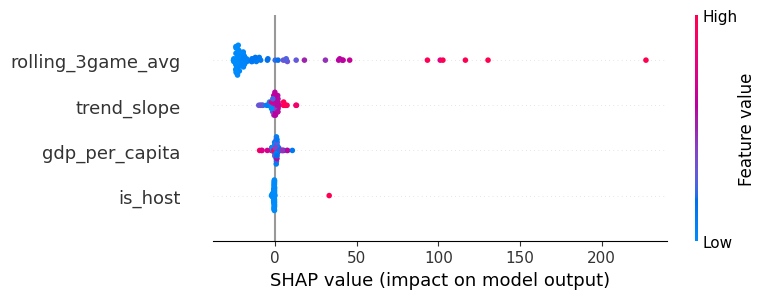

In [51]:
# SHAP feature importance
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.savefig('../data/processed/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP insights

- rolling_3game_avg is the dominant feature — past performance 
  predicts future performance better than any economic factor
- gdp_per_capita has a consistent positive effect for wealthy nations
- is_host shows a clear positive spike — confirms home field advantage
- trend_slope has the smallest impact — direction of change matters 
  less than absolute historical level

---
## 4. 2028 LA Predictions

### What I'm doing
Generating predictions for the 2028 Los Angeles Olympics. The USA gets `is_host = 1` and the home boost multiplier applied. All other countries get `is_host = 0`.

### Caveats
These are statistical predictions based on historical patterns. They do not account for unexpected events (injuries, geopolitical boycotts, new sports being added). Treat them as a data-informed estimate, not a forecast.

In [52]:
# Build 2028 prediction input
# Take each country's latest data and project forward
df_latest = df_model[df_model['Year'] == 2016].copy()

# Set 2028 specifics
df_latest['Year'] = 2028
df_latest['is_host'] = df_latest['NOC'].apply(lambda x: 1 if x == 'USA' else 0)

# Predict
predictions = df_latest.copy()
predictions['predicted_total'] = xgb.predict(df_latest[FEATURES]).astype(int)
predictions = predictions.sort_values('predicted_total', ascending=False)

print('Top 20 predicted countries for 2028 LA Olympics:')
print(predictions[['NOC', 'predicted_total']].head(20).to_string(index=False))

Top 20 predicted countries for 2028 LA Olympics:
NOC  predicted_total
USA              254
RUS              162
CHN              141
GBR              117
AUS              111
GER              107
FRA               81
JPN               73
KOR               69
ESP               67
NED               60
ITA               59
CAN               55
BRA               43
ARG               35
CUB               30
BLR               29
CRO               29
HUN               29
MEX               26


In [53]:
# Isolate home field advantage effect
usa_host = predictions[predictions['NOC'] == 'USA']['predicted_total'].values[0]

# Predict USA without host flag
usa_no_host = df_latest[df_latest['NOC'] == 'USA'].copy()
usa_no_host['is_host'] = 0
usa_predicted_no_host = xgb.predict(usa_no_host[FEATURES]).astype(int)[0]

print(f'USA predicted WITH host advantage:    {usa_host} medals')
print(f'USA predicted WITHOUT host advantage: {usa_predicted_no_host} medals')
print(f'Home field advantage effect:          +{usa_host - usa_predicted_no_host} medals')

USA predicted WITH host advantage:    254 medals
USA predicted WITHOUT host advantage: 246 medals
Home field advantage effect:          +8 medals


## 2028 LA predictions — key findings

- USA predicted to win 254 medals — dominant even without home advantage
- Home field advantage effect for USA: +8 medals
- This is relatively small because USA already has the highest rolling average
- Home advantage matters more for smaller nations who benefit from 
  crowd support and reduced travel fatigue

Note: absolute medal counts may be overestimated due to sport count 
differences between 1960-2016 era and modern Olympics.
Relative rankings are more reliable than absolute numbers.

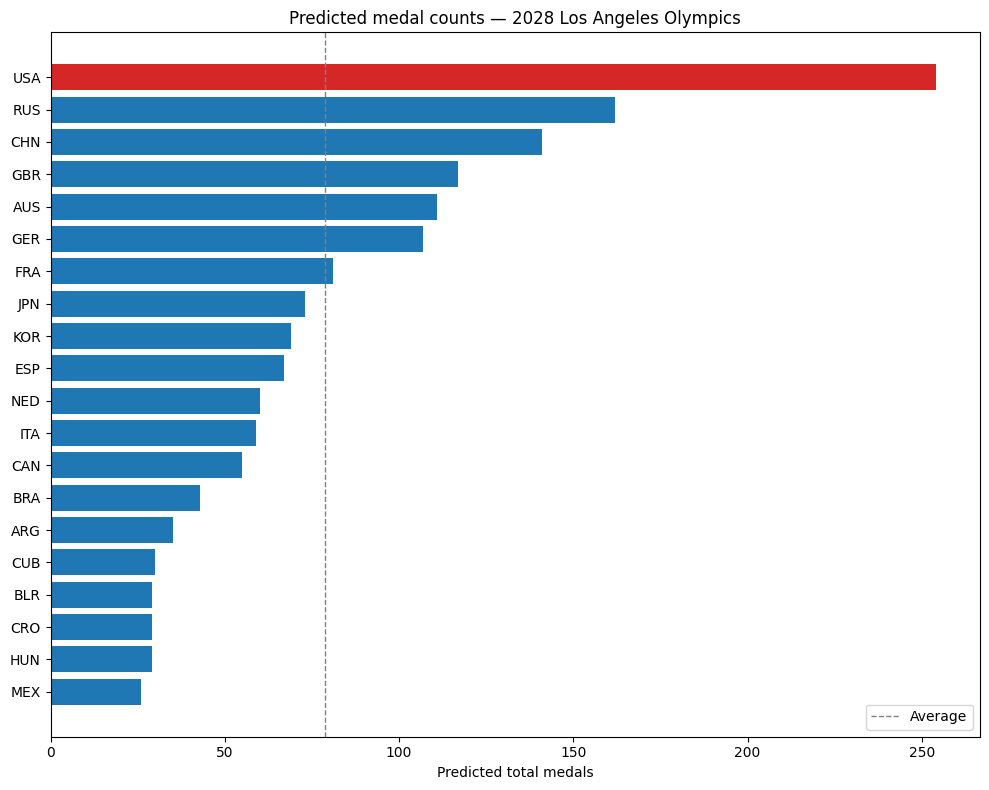

In [54]:
fig, ax = plt.subplots(figsize=(10, 8))

top20 = predictions.head(20)
colors = ['#1f77b4' if noc != 'USA' else '#d62728' for noc in top20['NOC']]

ax.barh(top20['NOC'][::-1], top20['predicted_total'][::-1], color=colors[::-1])
ax.set_xlabel('Predicted total medals')
ax.set_title('Predicted medal counts — 2028 Los Angeles Olympics')
ax.axvline(x=top20['predicted_total'].mean(), color='gray', linestyle='--', linewidth=1, label='Average')
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/predictions_2028.png', dpi=150)
plt.show()

---
## Conclusions

### What I found
- XGBoost significantly outperformed Poisson regression (MAE 9.35 vs 17.45)
- Past performance (rolling_3game_avg) is the strongest predictor of future medals
- Home field advantage adds ~8 medals for USA — relatively small because 
  USA already dominates regardless of location
- GDP per capita has consistent positive effect but is secondary to historical form

### What surprised me
- How much rolling average dominates over economic factors — 
  wealthy nations don't automatically win more if they lack Olympic tradition
- Croatia appearing in top 20 predictions

### What I would do differently
- Find a more recent dataset that includes 2020 and 2024 results
- Add sport-specific predictions (athletics, swimming separately)
- Include population as a feature alongside GDP